In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import re
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [2]:
data = pd.read_csv("data_C.csv")
print(data.shape)
print(data.dtypes)
data.head()

(25000, 29)
Number                        int64
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance 

,Number,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897592,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574717,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [3]:
for col in data.columns:
    print(repr(col))

'Number'
'ID'
'Customer_ID'
'Month'
'Name'
'Age'
'SSN'
'Occupation'
'Annual_Income'
'Monthly_Inhand_Salary'
'Num_Bank_Accounts'
'Num_Credit_Card'
'Interest_Rate'
'Num_of_Loan'
'Type_of_Loan'
'Delay_from_due_date'
'Num_of_Delayed_Payment'
'Changed_Credit_Limit'
'Num_Credit_Inquiries'
'Credit_Mix'
'Outstanding_Debt'
'Credit_Utilization_Ratio'
'Credit_History_Age'
'Payment_of_Min_Amount'
'Total_EMI_per_month'
'Amount_invested_monthly'
'Payment_Behaviour'
'Monthly_Balance'
'Credit_Score'


In [4]:
print("\nTarget distribution:\n", data['Credit_Score'].value_counts())


Target distribution:
 Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64


In [5]:
print(data.isnull().sum())
print(data.isnull().any(axis=1).sum())

Number                         0
ID                             0
Customer_ID                    0
Month                          0
Name                        2430
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2852
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit           0
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64
11711


In [6]:
data.head()

,Number,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897592,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574717,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [7]:
dropped_cols = ['Number', 'ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan']
data = data.drop(columns=dropped_cols)

In [8]:
print(data.isnull().sum())

Age                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit           0
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
dtype: int64


In [9]:
print(data.dtypes)

Age                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object


In [10]:
def parse_credit_age(val):
    if pd.isna(val):
        return np.nan
    years = re.search(r'(\d+)\s*Year', str(val))
    months = re.search(r'(\d+)\s*Month', str(val))
    total = 0
    if years: total += int(years.group(1)) * 12
    if months: total += int(months.group(1))
    return total if total > 0 else np.nan

data['Credit_History_Months'] = data['Credit_History_Age'].apply(parse_credit_age)
data = data.drop(columns=['Credit_History_Age'])


data['Num_of_Loan'] = data['Num_of_Loan'].astype(str).str.replace('_', '', regex=False)
data['Num_of_Loan'] = pd.to_numeric(data['Num_of_Loan'], errors='coerce')
data['Num_of_Loan'] = data['Num_of_Loan'].clip(lower=0)

data['Changed_Credit_Limit'] = data['Changed_Credit_Limit'].replace('_', np.nan)  

data['Occupation'] = data['Occupation'].replace('_______', 'Unknown')
data['Payment_Behaviour'] = data['Payment_Behaviour'].replace('!@9#%8', np.nan)
payment_mode = data['Payment_Behaviour'].mode()[0]
data['Payment_Behaviour'] = data['Payment_Behaviour'].fillna(payment_mode)
data['Payment_of_Min_Amount'] = data['Payment_of_Min_Amount'].replace('NM', 'Unknown')

numeric_cols = ['Annual_Income', 'Age', 'Changed_Credit_Limit', 'Outstanding_Debt','Amount_invested_monthly', 'Num_of_Delayed_Payment', 'Num_of_Loan', 'Changed_Credit_Limit']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Dtypes after cleaning:\n", data.dtypes)
print("\nMissing values after cleaning:\n", data.isnull().sum())

Dtypes after cleaning:
 Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
Credit_History_Months       float64
dtype: object

Missing values after cleaning:
 Age                         1245
Occupation                     0
Annual_Income               1778
Monthly_Inhand_Salary       3836
Num_B

In [11]:
print(data.isnull().sum())

Age                         1245
Occupation                     0
Annual_Income               1778
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Delay_from_due_date            0
Num_of_Delayed_Payment      2495
Changed_Credit_Limit         518
Num_Credit_Inquiries         472
Credit_Mix                     0
Outstanding_Debt             270
Credit_Utilization_Ratio       0
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2183
Payment_Behaviour              0
Monthly_Balance              301
Credit_Score                   0
Credit_History_Months       2240
dtype: int64


In [12]:
X = data.drop(columns=['Credit_Score'])
y = data['Credit_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numerical features:", num_cols)
print("\nCategorical features:", cat_cols)

Numerical features: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months']

Categorical features: ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [13]:
def iqr_median_impute_fit(train_col):
    Q1 = train_col.quantile(0.25)
    Q3 = train_col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    robust_median = train_col[(train_col >= lower) & (train_col <= upper)].median()
    return robust_median

impute_cols = [
    'Monthly_Inhand_Salary',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
    'Credit_History_Months',
    'Outstanding_Debt',
    'Age',
    'Annual_Income',
    'Changed_Credit_Limit'
]

# Fit on train, apply to both
impute_values = {}
for col in impute_cols:
    robust_median = iqr_median_impute_fit(X_train[col])
    impute_values[col] = robust_median
    X_train[col] = X_train[col].fillna(robust_median)
    X_test[col] = X_test[col].fillna(robust_median)  
    print(f"{col}: imputed with {robust_median:.2f}")

Monthly_Inhand_Salary: imputed with 3001.92
Amount_invested_monthly: imputed with 116.61
Monthly_Balance: imputed with 323.48
Num_of_Delayed_Payment: imputed with 14.00
Num_Credit_Inquiries: imputed with 5.00
Credit_History_Months: imputed with 219.00
Outstanding_Debt: imputed with 1092.14
Age: imputed with 33.00
Annual_Income: imputed with 35871.70
Changed_Credit_Limit: imputed with 9.38


In [14]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_History_Months       0
dtype: int64
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries       

In [15]:
encoders = {}
for col in cat_cols:
    encoding = LabelEncoder()
    X_train[col] = encoding.fit_transform(X_train[col].astype(str))
    X_test[col] = encoding.transform(X_test[col].astype(str))  
    encoders[col] = encoding

# Encode target
encoding_target = LabelEncoder()
y_train = encoding_target.fit_transform(y_train)
y_test = encoding_target.transform(y_test)
print("Class mapping:", dict(zip(encoding_target.classes_, encoding_target.transform(encoding_target.classes_))))

Class mapping: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}


In [16]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  
X_test[num_cols] = scaler.transform(X_test[num_cols])         

print("Preprocessing complete.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Preprocessing complete.
X_train shape: (20000, 21)
X_test shape: (5000, 21)


In [17]:
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test :", X_test.isnull().sum().sum())

NaNs in X_train: 0
NaNs in X_test : 0


In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results[name] = {'Accuracy': acc, 'F1-Score (macro)': f1}
    print(f"  Accuracy: {acc:.4f} | F1 (macro): {f1:.4f}")

results_df = pd.DataFrame(results).T
print("\n=== EXPERIMENT RESULTS ===")
print(results_df.sort_values('F1-Score (macro)', ascending=False))


Training: Logistic Regression...
  Accuracy: 0.6108 | F1 (macro): 0.5579

Training: Decision Tree...
  Accuracy: 0.6208 | F1 (macro): 0.5934

Training: Random Forest...
  Accuracy: 0.7388 | F1 (macro): 0.7205

Training: Gradient Boosting...
  Accuracy: 0.7008 | F1 (macro): 0.6757

Training: XGBoost...


C:\Users\Cristopher\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:31:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.7148 | F1 (macro): 0.6936

=== EXPERIMENT RESULTS ===
                     Accuracy  F1-Score (macro)
Random Forest          0.7388          0.720457
XGBoost                0.7148          0.693568
Gradient Boosting      0.7008          0.675705
Decision Tree          0.6208          0.593438
Logistic Regression    0.6108          0.557907


Best model: Random Forest

=== Classification Report ===
              precision    recall  f1-score   support

        Good       0.64      0.68      0.66       890
        Poor       0.75      0.72      0.74      1454
    Standard       0.77      0.77      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



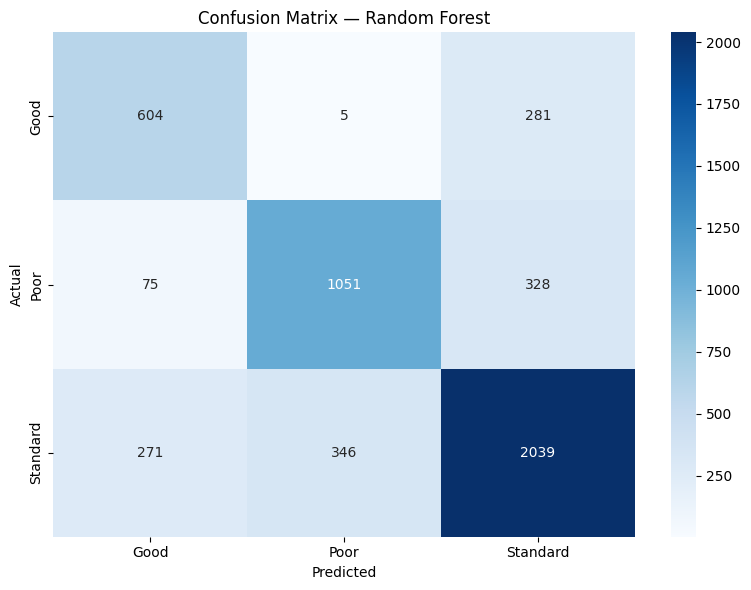

In [20]:
# Identify best model
best_model_name = results_df['F1-Score (macro)'].idxmax()
best_model = models[best_model_name]

print(f"Best model: {best_model_name}\n")

y_pred_best = best_model.predict(X_test)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred_best, target_names=encoding_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoding_target.classes_,
            yticklabels=encoding_target.classes_)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

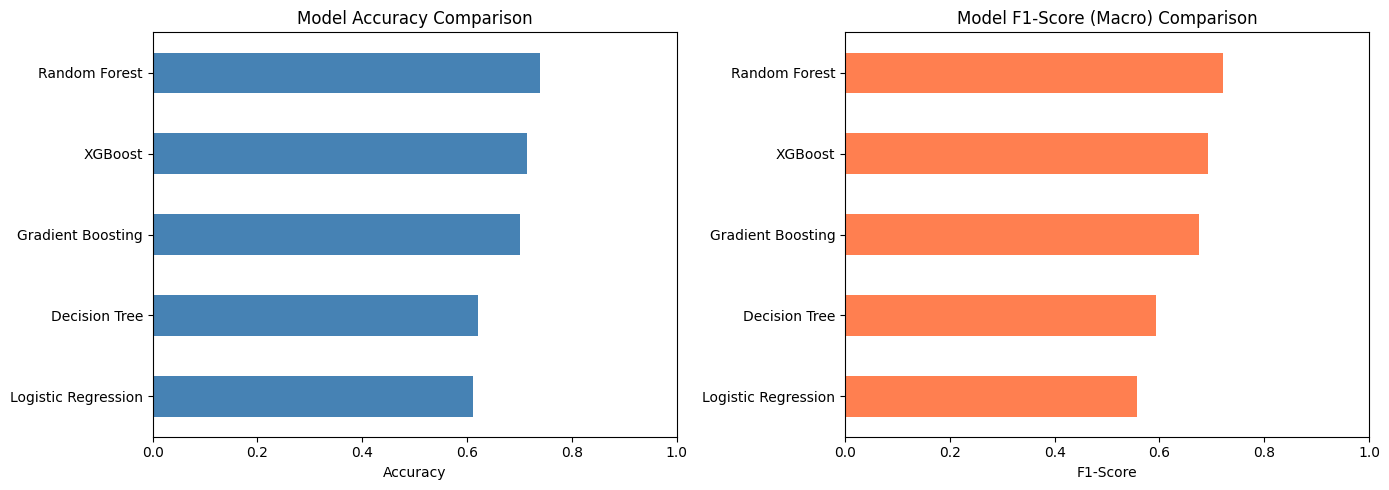

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['Accuracy'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1)

results_df['F1-Score (macro)'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Model F1-Score (Macro) Comparison')
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

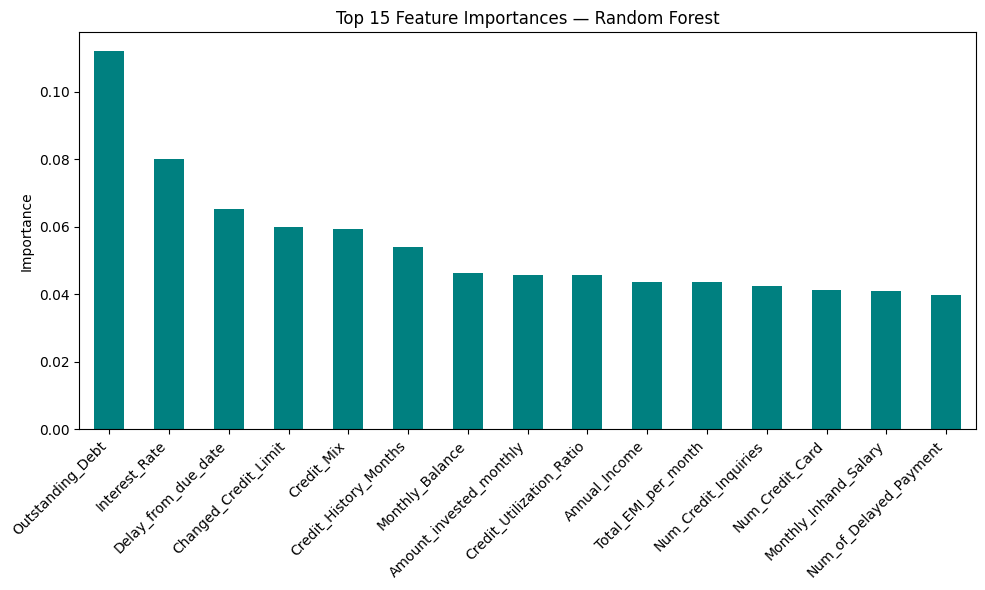

In [23]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances_sorted = importances.sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 6))
    importances_sorted.plot(kind='bar', color='teal')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.ylabel('Importance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} tidak memiliki feature_importances_. Lewati cell ini.")

In [ ]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")

client = mlflow.tracking.MlflowClient()
versions = client.get_latest_versions("CreditScoreClassifier")
for v in versions:
    print(f"Version: {v.version}, Run ID: {v.run_id}")

Version: 2, Run ID: 5c128381af2343e39f89ca638f191b50


C:\Users\Cristopher\AppData\Local\Temp\ipykernel_28572\2492238010.py:5: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  versions = client.get_latest_versions("CreditScoreClassifier")


In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
model = mlflow.sklearn.load_model("runs:/5c128381af2343e39f89ca638f191b50/best_model")
print(model.feature_names_in_)

['Age' 'Occupation' 'Annual_Income' 'Monthly_Inhand_Salary'
 'Num_Bank_Accounts' 'Num_Credit_Card' 'Interest_Rate' 'Num_of_Loan'
 'Delay_from_due_date' 'Num_of_Delayed_Payment' 'Changed_Credit_Limit'
 'Num_Credit_Inquiries' 'Credit_Mix' 'Outstanding_Debt'
 'Credit_Utilization_Ratio' 'Payment_of_Min_Amount' 'Total_EMI_per_month'
 'Amount_invested_monthly' 'Payment_Behaviour' 'Monthly_Balance'
 'Credit_History_Months']
